# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZainDev04/Flyrank-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

**Lane 3 — Structured Content Archetype Clustering.**

Seven weeks of work becomes one thing here: **a list a content lead can act on, with the limits attached
to it rather than filed somewhere else.** This is the recommendations section of next week's paper, so
every number in it has to trace back to a committed receipt.

**Three things this playbook does that a score alone would not:**

1. It ships **five** archetypes, not six — ML-09 withdrew one, and the playbook honours that.
2. It has an explicit **low-confidence bucket**. Roughly a tenth of pages sit near a boundary and get
   `monitor` regardless of which archetype they fell into.
3. It reports a **negative result** on the refresh lever, because on this slice the association I expected
   is not there — and a playbook that hides that is not a playbook, it is marketing.

> Skills for this card: `skills/writing-honest-claims/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`.
> Data: `data/raw/content_refresh_anonymized.csv`. Seed 42. Everything frozen from ML-08 / ML-09.

In [1]:
import os, sys, json, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

SEED = 42
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/ZainDev04/Flyrank-ML-Internship"
CSV_REL  = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir("Flyrank-ML-Internship"):
        subprocess.run(["git","clone","--depth","1",REPO_URL,"Flyrank-ML-Internship"], check=True)
    os.chdir("Flyrank-ML-Internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

MIN_IMPRESSIONS, K = 300, 6            # frozen from ML-02
df = pd.read_csv(CSV_REL)
d = df[(df["impressions_90d"] >= MIN_IMPRESSIONS) & (df["avg_position"] > 0)].copy()
d["log_impressions"] = np.log1p(d["impressions_90d"])
d["log_clicks"] = np.log1p(d["clicks_90d"])
d["log_sessions"] = np.log1p(d["sessions_90d"])
d["impression_consistency"] = d["days_with_impressions"] / 90
d = d.reset_index(drop=True)

FEATURES = ["log_impressions","log_clicks","ctr","avg_position","log_sessions",
            "engagement_rate","impression_consistency","content_age_days","days_since_last_update"]
X = StandardScaler().fit_transform(d[FEATURES].fillna(d[FEATURES].median()))
km = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit(X)
d["cluster"] = km.labels_

# per-page confidence, from ML-09's error analysis
d["silhouette"] = silhouette_samples(X, km.labels_)

print(f"sklearn {sklearn.__version__} | seed {SEED}")
print(f"inventory: {len(d):,} pages / {d['client_id'].nunique()} clients")
print(f"cluster sizes: {sorted(pd.Series(km.labels_).value_counts().tolist())}")
print("ML-08 / ML-09 state reproduced.")

sklearn 1.8.0 | seed 42
inventory: 18,752 pages / 29 clients
cluster sizes: [537, 985, 3595, 4113, 4598, 4924]
ML-08 / ML-09 state reproduced.


## 1. Ranked actions + reason codes

### The archetype → action mapping

Five archetypes carry an action. The sixth was withdrawn in ML-09 and its pages fall through to whichever
group they join — the playbook does not pretend it exists.

| Archetype | Pages | Action | Reason code a reviewer sees | Why this action |
|---|---:|---|---|---|
| **High-Yield Core** | 4,924 | `protect` | `PERFORMING_DO_NOT_DISTURB` | 13,478 median impressions, 0.36% CTR, position 7.4. The risk here is breaking it. |
| **Long-Form Untouched** | 4,598 | `improve` | `LONG_AND_UNTOUCHED` | 4,428 median words, 104 days since update, real exposure. An editorial handle exists. |
| **Long-Tenured Plateau** | 3,595 | `rewrite` | `SETTLED_LOW_AFTER_LONG_RUN` | 445 median days old at 0.10% CTR. It has had its chance at this shape. |
| **Recently Published, Establishing** | 4,113 | `monitor` | `TOO_EARLY_TO_JUDGE` | Youngest cohort (119 days) at ordinary volume. Ask again in 90 days. |
| **Intermittent Exposure** | 985 | `monitor` | `EXPOSURE_UNSTABLE` | Impressions on ~60% of days. Nothing can be judged until exposure steadies. |
| *~~Measured-Engagement Minority~~* | — | **withdrawn** | — | ML-09: does not survive removing `engagement_rate`; no reduced-run cluster recovers it. |

**`prune` and `merge` are absent from this vocabulary.** ML-02 committed to never recommending removal on
cluster membership alone, and nothing in seven weeks changed that. A `prune` recommendation would need a
consolidation check this data cannot support.

### The ranking, and why it is ranked at all

An archetype tells a reviewer *what kind* of page this is. It does not tell them *which one to open on
Monday*. So each page carries a **review priority** — a transparent score, no fitted weights:

```python
review_priority = action_weight[archetype] * log1p(impressions_90d) * confidence_multiplier
```

- `action_weight` is a policy I set and defend: `rewrite` 1.0, `improve` 0.9, `monitor` 0.3,
  `protect` 0.1. Protect ranks lowest because a protect list should never crowd out a fix list.
- `log1p(impressions)` breaks ties by what is at stake, without letting the biggest pages own the queue.
- `confidence_multiplier` is the new part, and it comes from ML-09.

In [2]:
NAMES = {0:"Long-Tenured Plateau", 1:"Long-Form Untouched", 2:"High-Yield Core",
         3:"Intermittent Exposure", 4:"Recently Published, Establishing",
         5:"Measured-Engagement Minority (WITHDRAWN)"}
ACTIONS = {0:"rewrite", 1:"improve", 2:"protect", 3:"monitor", 4:"monitor", 5:"monitor"}
REASONS = {0:"SETTLED_LOW_AFTER_LONG_RUN", 1:"LONG_AND_UNTOUCHED", 2:"PERFORMING_DO_NOT_DISTURB",
           3:"EXPOSURE_UNSTABLE", 4:"TOO_EARLY_TO_JUDGE", 5:"ARCHETYPE_WITHDRAWN"}
ACTION_WEIGHT = {"rewrite":1.0, "improve":0.9, "monitor":0.3, "protect":0.1}

CONFIDENCE_FLOOR = 0.05        # policy: ML-09 measured ~10% of pages below this
d["archetype"] = d["cluster"].map(NAMES)
d["action"] = d["cluster"].map(ACTIONS)
d["reason_code"] = d["cluster"].map(REASONS)

# --- the ML-09 promise, implemented ---
low_conf = d["silhouette"] < CONFIDENCE_FLOOR
withdrawn = d["cluster"] == 5
d["confidence"] = np.where(low_conf, "low", "standard")
d.loc[low_conf, "action"] = "monitor"
d.loc[low_conf, "reason_code"] = "BOUNDARY_CASE_LOW_CONFIDENCE"
d.loc[withdrawn, "confidence"] = "low"
d.loc[withdrawn, "reason_code"] = "ARCHETYPE_WITHDRAWN"

d["confidence_multiplier"] = np.where(d["confidence"] == "low", 0.5, 1.0)
d["review_priority"] = (d["action"].map(ACTION_WEIGHT)
                        * np.log1p(d["imp" "ressions_90d"])
                        * d["confidence_multiplier"])

d = d.sort_values(["review_priority","impressions_90d","content_id"],
                  ascending=[False,False,True]).reset_index(drop=True)
d["rank"] = np.arange(1, len(d)+1)

print(f"pages routed to 'monitor' by the confidence floor : {int(low_conf.sum()):,} "
      f"({low_conf.mean()*100:.1f}%)")
print(f"pages in the withdrawn archetype (also low conf)  : {int(withdrawn.sum()):,}\n")
print("ACTION MIX (after confidence routing):")
print(d["action"].value_counts().to_string())
print("\nREASON CODE MIX:")
print(d["reason_code"].value_counts().to_string())
print(f"\nprune / merge recommendations issued: "
      f"{int(d['action'].isin(['prune','merge']).sum())}   <- zero, by design")

pages routed to 'monitor' by the confidence floor : 2,099 (11.2%)
pages in the withdrawn archetype (also low conf)  : 537

ACTION MIX (after confidence routing):
action
monitor    7153
improve    4504
protect    3693
rewrite    3402

REASON CODE MIX:
reason_code
LONG_AND_UNTOUCHED              4504
TOO_EARLY_TO_JUDGE              4058
PERFORMING_DO_NOT_DISTURB       3693
SETTLED_LOW_AFTER_LONG_RUN      3402
BOUNDARY_CASE_LOW_CONFIDENCE    1915
EXPOSURE_UNSTABLE                643
ARCHETYPE_WITHDRAWN              537

prune / merge recommendations issued: 0   <- zero, by design


In [3]:
cols = ["rank","content_id","client_id","archetype","action","reason_code","confidence",
        "review_priority","impressions_90d","clicks_90d","ctr","avg_position",
        "content_age_days","days_since_last_update","word_count"]
print("TOP 15 OF THE QUEUE - what a reviewer opens first\n")
print(d.head(15)[["rank","content_id","action","reason_code","confidence",
                  "impressions_90d","ctr","avg_position","content_age_days",
                  "days_since_last_update"]].to_string(index=False))
print("\nNOTE, and it is the same criticism ML-07 made of its own ladder: the top of this")
print("queue is dominated by ONE action, because I gave 'rewrite' weight 1.0. The ordering is")
print("my policy, not a discovery. A team that would rather spend the week on 'improve' should")
print("change that weight and regenerate - a one-line edit, and it is meant to be.")
print("\narchetype mix in the top 200:")
print(d.head(200)["archetype"].value_counts().to_string())
print(f"\ndistinct clients in the top 200: {d.head(200)['client_id'].nunique()} of "
      f"{d['client_id'].nunique()}  |  largest client share: "
      f"{d.head(200)['client_id'].value_counts().iloc[0]/200*100:.0f}%")

TOP 15 OF THE QUEUE - what a reviewer opens first

 rank           content_id  action                reason_code confidence  impressions_90d  ctr  avg_position  content_age_days  days_since_last_update
    1 content_c8e9d6ab9013 improve         LONG_AND_UNTOUCHED   standard           208678 0.00           9.7               362                     104
    2 content_2cb8b923f6d8 rewrite SETTLED_LOW_AFTER_LONG_RUN   standard            34796 0.05          36.0               445                      20
    3 content_609902f4bc8c rewrite SETTLED_LOW_AFTER_LONG_RUN   standard            31756 0.07           6.4               537                      34
    4 content_fb4bf6555c79 improve         LONG_AND_UNTOUCHED   standard            84093 0.00          45.6               299                     104
    5 content_de58f5f7ea8b rewrite SETTLED_LOW_AFTER_LONG_RUN   standard            25970 0.05           8.4               419                      20
    6 content_021638284be1 rewrite SETTLED_

### The decay / refresh insight — and it is a negative one

The FlyRank paper's most dramatic finding is that *"365+ day content that was refreshed within 30 days
shows 3.2x health boost and 57x more impressions."* ML-09 asked whether that was a within-page change or a
between-group comparison. Here I run the between-group version on my own slice, because if the refresh
lever works on this population my playbook should say so loudly.

In [4]:
old = df[df["content_age_days"] >= 365].copy()
old["refreshed_within_30d"] = old["days_since_last_update"] <= 30

full = old.groupby("refreshed_within_30d").agg(
    pages=("content_id","size"), median_impressions=("impressions_90d","median"),
    mean_impressions=("impressions_90d","mean"), median_ctr=("ctr","median"),
    median_position=("avg_position","median"))
print("A) the paper's comparison SHAPE, on the whole 30k starter slice (365+ day content):\n")
print(full.round(2).to_string())
ratio_full = full.loc[True,"median_impressions"] / max(full.loc[False,"median_impressions"], 1)
print(f"\n   median impression ratio (refreshed / not refreshed): {ratio_full:.2f}x")

vis = old[(old["impressions_90d"] >= MIN_IMPRESSIONS) & (old["avg_position"] > 0)]
g2 = vis.groupby("refreshed_within_30d").agg(
    pages=("content_id","size"), median_impressions=("impressions_90d","median"),
    median_ctr=("ctr","median"))
print("\nB) the same comparison INSIDE my playbook's eligible population:\n")
print(g2.round(2).to_string())
print(f"\n   median impression ratio: "
      f"{g2.loc[True,'median_impressions']/max(g2.loc[False,'median_impressions'],1):.2f}x")

removed = df[~((df["impressions_90d"] >= MIN_IMPRESSIONS) & (df["avg_position"] > 0))]
print(f"\nC) who my visibility filter removes: {len(removed):,} of {len(df):,} pages "
      f"({len(removed)/len(df)*100:.0f}%), median impressions_90d = "
      f"{removed['impressions_90d'].median():.0f}")
print(f"   (the paper's un-refreshed baseline group sits at 71 median impressions - "
      f"that is the population my filter removes)")

A) the paper's comparison SHAPE, on the whole 30k starter slice (365+ day content):

                      pages  median_impressions  mean_impressions  median_ctr  median_position
refreshed_within_30d                                                                          
False                   553              1159.0           7431.82        0.09             12.2
True                   5807               817.0           4968.24        0.06             14.1

   median impression ratio (refreshed / not refreshed): 0.70x

B) the same comparison INSIDE my playbook's eligible population:

                      pages  median_impressions  median_ctr
refreshed_within_30d                                       
False                   449              1642.0        0.12
True                   4026              1748.5        0.13

   median impression ratio: 1.06x

C) who my visibility filter removes: 11,248 of 30,000 pages (37%), median impressions_90d = 31
   (the paper's un-refreshed basel

**Read, carefully — this is a negative result and it needs its caveats in the same breath.**

On this slice I **could not reproduce the direction** of the refresh finding. Among 365+ day content,
recently-refreshed pages showed **0.70×** the median impressions of untouched ones on the full slice, and
**1.06×** — essentially flat — inside my playbook's visible population.

**What that does and does not mean:**

- **It is not evidence the paper is wrong.** Different data (a 30,000-row anonymized teaching slice against
  341,701 pieces across 57 brands), possibly a different definition of "refreshed", and — the part that
  matters most — **a different population**. The paper's un-refreshed baseline sits at **71 median
  impressions**. My filter removes 11,248 pages whose median is **31 impressions**. The contrast the paper
  reports is anchored on precisely the near-invisible tail my playbook excludes by design.
- **The direction on the full slice (0.70×) is worth flagging as a selection story**, not a reversal. If
  editors refresh pages that are struggling, the refreshed group is the weaker group *before* anyone
  touches it — the mirror image of the selection concern I raised about the paper in ML-09, pointing the
  other way. I cannot separate those without a within-page before/after, which this data does not support.
- **n on the un-refreshed side is small**: 553 pages on the full slice, 449 in the eligible population.

**What the playbook does with it.** Nothing changes about `Long-Form Untouched` → `improve`, because that
action rests on *"this page has an editorial handle and real exposure"*, not on *"refreshing raises
impressions"*. But the playbook adds an explicit rule:

> **Refresh recency is not a priority signal in this playbook.** On this population, being recently
> refreshed showed no measured association with higher visibility. A reviewer should not open a page
> because it is stale, nor skip one because it is fresh.

That is a rule I would have got wrong if I had imported the paper's headline instead of testing it here.

## 2. Intended use and limits

### Who this is for, and what they do with it
A **content lead setting policy across an inventory**, and a **reviewer working a weekly queue**. The lead
reads the archetype→action table and decides which actions their team takes at all. The reviewer opens the
queue in order and, for each page, decides whether the suggested action applies.

**The output is a shortlist and a suggested treatment. It is not a decision.** Every row is a hypothesis
about where a human's attention is best spent.

### Where it is valid

| Valid | Not valid |
|---|---|
| Pages with ≥ 300 impressions in the 90-day window and recorded position data | The 37% of the slice below that bar — 11,248 pages with a median of 31 impressions |
| The 29 pseudonymized clients in this slice | A new client, until the archetypes are checked against them (ML-09: leave-one-client-out ARI 0.909, but 3 of 17 clients below 0.80, worst 0.465) |
| One trailing 90-day window | Any claim about trajectory — a plateau and a fresh start look identical from inside one window |
| Search-visibility behaviour | Engagement quality. ML-04 measured that only 4.2% of warehouse rows pass `ga4_data_available IS TRUE` |
| Ranking attention | Ranking value. No revenue, conversion or margin data is in scope |

### The claim ladder, applied to this playbook

- **Observed** — *"Across 18,752 pages from 29 pseudonymized clients, K-Means at k=6 produced six groups
  reproducing across seeds at ARI 0.998."*
- **Measured** — *"Five of six survive removing `engagement_rate`; leave-one-client-out gives mean ARI
  0.909 across 17 clients, with 3 below 0.80 and a worst case of 0.465."*
- **Directional** — *"Pages in Long-Tenured Plateau have had a long run at low CTR, which suggests their
  current shape is not working."*
- **Decision-support** — *"These pages look worth reviewing first, because…"*

**Never used anywhere in this project:** *proves*, *causes*, *will increase*, *the algorithm rewards*,
*guaranteed*, *deserves*. The last one took a deliberate edit in ML-09 — "these pages deserve a different
action" reads modest and is not.

## 3. Human review + the no-go list

### What a reviewer must check before acting — four questions, in order

In [5]:
CHECKLIST = pd.DataFrame([
 (1, "Is the archetype plausible for this page?",
     "Open it. If it reads nothing like its group's profile, mark the row wrong - that feedback is "
     "the retrain trigger in section 4, not a nuisance."),
 (2, "Is the exposure real, or a measurement artefact?",
     "A page with impressions but no position data, or a sudden spike, may be a tracking event rather "
     "than demand. avg_position == 0 already excluded 1,205 rows for exactly this reason."),
 (3, "Has someone already worked on this page?",
     "The features carry no intervention history. A page that looks unfixed may have been fixed last "
     "week - ML-08's three most confident errors were all pages a human had already touched."),
 (4, "Would the suggested action be reversible?",
     "'rewrite' on a page that is quietly serving a small, loyal audience is not reversible. If in "
     "doubt, downgrade to monitor. Nothing in this playbook is urgent enough to justify an "
     "irreversible action taken on a ranked list."),
], columns=["#","check","what it means in practice"])
for _, r in CHECKLIST.iterrows():
    print(f"{r['#']}. {r['check']}")
    print(f"   {r['what it means in practice']}\n")

print("REVIEW LOAD, so the plan is honest about capacity:")
for k in (20, 50, 200):
    top = d.head(k)
    print(f"  top {k:3d}: {top['action'].value_counts().to_dict()}")
print(f"\n  at 20 pages/week, the {len(d):,}-page inventory takes "
      f"{len(d)/20/52:.0f} years to review once.")
print("  That is the point of ranking - not to review everything, but to choose the first 20 well.")

1. Is the archetype plausible for this page?
   Open it. If it reads nothing like its group's profile, mark the row wrong - that feedback is the retrain trigger in section 4, not a nuisance.

2. Is the exposure real, or a measurement artefact?
   A page with impressions but no position data, or a sudden spike, may be a tracking event rather than demand. avg_position == 0 already excluded 1,205 rows for exactly this reason.

3. Has someone already worked on this page?
   The features carry no intervention history. A page that looks unfixed may have been fixed last week - ML-08's three most confident errors were all pages a human had already touched.

4. Would the suggested action be reversible?
   'rewrite' on a page that is quietly serving a small, loyal audience is not reversible. If in doubt, downgrade to monitor. Nothing in this playbook is urgent enough to justify an irreversible action taken on a ranked list.

REVIEW LOAD, so the plan is honest about capacity:
  top  20: {'rewrite

### The no-go list — what must never be automated

Written as rules, because a playbook that only says "use judgement" gives none.

| Never automate | Why |
|---|---|
| **Deleting, unpublishing or redirecting any page** | Cluster membership is a description of behaviour in one 90-day window. It is not evidence a page has no value. `prune` is not in this playbook's vocabulary at all. |
| **Rewriting content without a human reading it first** | The model has never seen the words on the page. It knows impressions, clicks, position, age and length — nothing about whether the content is correct, current or legally sensitive. |
| **Acting on a low-confidence row** | ML-09 found a page whose assigned archetype (`protect`) and runner-up (`rewrite`) were **0.1% apart in distance** — opposite actions decided by one part in a thousand. Those rows are routed to `monitor` here, and that routing must not be overridden by a bulk job. |
| **Applying the archetypes to a new client unchecked** | Leave-one-client-out ARI ranged 0.465–1.000. For some clients the structure simply does not transfer. |
| **Publishing any per-page number outside the team** | Every id here is a pseudonym for a real client's page. Aggregates are public-safe; rows are not. |
| **Treating `protect` as "ignore"** | It means *do not disturb*, not *do not watch*. A High-Yield Core page that starts sliding is the most expensive miss available. |

**And the meta-rule:** if a page's suggested action would be expensive to undo, the playbook is the wrong
input for that decision. It is built to allocate *attention*, and attention is cheap to reallocate.

## 4. Monitoring / retrain triggers

This is not a production system, and I am not going to write a monitoring plan that pretends otherwise.
What follows is the lightweight version a small team could actually run.

In [6]:
triggers = pd.DataFrame([
 ("Archetype mix shift",
  "share of pages in any archetype moves by more than 10 percentage points vs the frozen baseline below",
  "monthly", "Re-profile before re-clustering. A mix shift usually means the inventory changed, not "
             "that the model broke."),
 ("Low-confidence share climbs",
  f"share of pages below silhouette {CONFIDENCE_FLOOR} rises above 20% (currently "
  f"{(d['silhouette'] < CONFIDENCE_FLOOR).mean()*100:.1f}%; total low-confidence share is "
  f"{(d['confidence']=='low').mean()*100:.1f}% once the withdrawn archetype is included)",
  "monthly", "The clusters are losing their edges. Re-run k selection - the silhouette curve was already "
             "nearly flat between k=5 and k=8."),
 ("Reviewer disagreement",
  "reviewers mark the archetype 'wrong' on more than 1 in 4 of the pages they open",
  "continuous", "The strongest signal available, and the cheapest. Human disagreement outranks any "
                "internal metric here."),
 ("New client onboarded",
  "any client not in the 29 used to fit these archetypes",
  "on event", "Run leave-one-client-out for that client BEFORE using the queue on them. 3 of 17 "
              "scored below 0.80."),
 ("Window staleness",
  "the 90-day window underlying the queue is more than 30 days old",
  "monthly", "Regenerate. The queue is a snapshot; it does not age gracefully."),
 ("Engagement coverage improves",
  "a slice arrives where GA4 coverage is materially above the 4.2% measured in ML-04",
  "on event", "Re-test the withdrawn archetype. It may be real and unmeasurable here rather than "
              "not real - those are different."),
], columns=["trigger","threshold","cadence","what to do"])
for _, r in triggers.iterrows():
    print(f"[{r['cadence']:10s}] {r['trigger']}")
    print(f"   trigger : {r['threshold']}")
    print(f"   action  : {r['what to do']}\n")

baseline_mix = (d["archetype"].value_counts(normalize=True)*100).round(1)
print("FROZEN BASELINE MIX - the thing monitoring compares against:")
print(baseline_mix.to_string())

[monthly   ] Archetype mix shift
   trigger : share of pages in any archetype moves by more than 10 percentage points vs the frozen baseline below
   action  : Re-profile before re-clustering. A mix shift usually means the inventory changed, not that the model broke.

[monthly   ] Low-confidence share climbs
   trigger : share of pages below silhouette 0.05 rises above 20% (currently 11.2%; total low-confidence share is 13.1% once the withdrawn archetype is included)
   action  : The clusters are losing their edges. Re-run k selection - the silhouette curve was already nearly flat between k=5 and k=8.

[continuous] Reviewer disagreement
   trigger : reviewers mark the archetype 'wrong' on more than 1 in 4 of the pages they open
   action  : The strongest signal available, and the cheapest. Human disagreement outranks any internal metric here.

[on event  ] New client onboarded
   trigger : any client not in the 29 used to fit these archetypes
   action  : Run leave-one-client-out for t

### Cost and value thinking, stated plainly

I have no revenue data, so I am not going to produce an ROI figure. What I can do is state the cost side
honestly, because that is the half a reviewer actually experiences.

**What an action costs, roughly, in reviewer time:**

| Action | Typical effort | Reversible? |
|---|---|---|
| `monitor` | minutes — a glance | fully |
| `protect` | minutes — set a watch | fully |
| `improve` | hours — edit a long page | mostly |
| `rewrite` | a day or more | poorly |

**The value side, and its honest limit.** The queue is sorted by `log1p(impressions)` within an action
weight, so a reviewer working top-down is spending their time where the most *exposure* sits. Exposure is
not value — a page with 40,000 impressions on tangential queries may be worth less than one with 2,000 on
commercial intent. **This playbook cannot tell those apart**, because no revenue, conversion or margin data
is in scope. `main_intent` is in the dataset and would be the first place to look for a value proxy; I have
deliberately not used it as one, because "transactional intent" is not the same as "makes money".

**The one cost/value rule I will defend:** because `rewrite` is the expensive, least reversible action and
it is attached to the archetype with the *weakest* internal evidence (a plateau is an absence of movement,
not a diagnosis), **`rewrite` rows should be sampled and read before the action is taken at scale.** Ten
pages read is cheap; 3,595 pages rewritten on a cluster label is not.

## 5. Exports for the paper

In [7]:
OUT = Path("work/outputs"); OUT.mkdir(parents=True, exist_ok=True)
FIG = Path("work/figures"); FIG.mkdir(parents=True, exist_ok=True)

# ---------- the ranked queue (regenerated every run; gitignored by design) ----------
QUEUE_COLS = ["rank","content_id","client_id","archetype","action","reason_code","confidence",
              "review_priority","impressions_90d","clicks_90d","ctr","avg_position",
              "content_age_days","days_since_last_update","word_count","impression_tier",
              "position_tier"]
queue_path = OUT / "action_playbook_queue.csv"
d[QUEUE_COLS].to_csv(queue_path, index=False)
print(f"wrote {queue_path}  ({len(d):,} rows x {len(QUEUE_COLS)} cols)")
print("     ^ gitignored by design (work/**/*.csv) - the notebook regenerates it\n")

# ---------- the receipts the paper's numbers trace back to ----------
playbook = {
    "notebook": "w07_action_playbook.ipynb",
    "lane": "Lane 3 - Structured Content Archetype Clustering",
    "seed": SEED, "sklearn": sklearn.__version__,
    "inventory": {"pages": int(len(d)), "clients": int(d["client_id"].nunique()),
                  "min_impressions": MIN_IMPRESSIONS,
                  "excluded_pages": int(len(df) - len(d)),
                  "excluded_median_impressions": float(
                      df[~df["content_id"].isin(d["content_id"])]["impressions_90d"].median())},
    "archetypes_active": 5, "archetypes_withdrawn": ["Measured-Engagement Minority"],
    "confidence_floor_silhouette": CONFIDENCE_FLOOR,
    "low_confidence_share_pct": round(float((d["confidence"]=="low").mean()*100), 2),
    "action_weights": ACTION_WEIGHT,
    "action_mix": {k: int(v) for k, v in d["action"].value_counts().items()},
    "reason_code_mix": {k: int(v) for k, v in d["reason_code"].value_counts().items()},
    "baseline_archetype_mix_pct": {k: float(v) for k, v in baseline_mix.items()},
    "refresh_finding": {
        "claim": "no measured association between recent refresh and higher visibility on this slice",
        "full_slice_median_impression_ratio": round(float(ratio_full), 3),
        "eligible_slice_median_impression_ratio": round(float(
            g2.loc[True,"median_impressions"]/max(g2.loc[False,"median_impressions"],1)), 3),
        "n_not_refreshed_full": int(full.loc[False,"pages"]),
        "caveat": ("different population from the published paper; the paper's baseline group sits at "
                   "71 median impressions, which this playbook's visibility filter removes"),
    },
    "never_automate": ["delete/unpublish/redirect", "rewrite without human reading",
                       "act on low-confidence rows", "apply to an unchecked new client",
                       "publish per-page rows externally"],
    "traces_to": ["work/outputs/baseline_metrics.json", "work/outputs/model_metrics.json",
                  "work/outputs/validation_metrics.json"],
}
(OUT / "playbook_metrics.json").write_text(json.dumps(playbook, indent=2))
print(f"wrote {OUT/'playbook_metrics.json'}  <- COMMIT THIS (the paper's receipts)")

wrote work/outputs/action_playbook_queue.csv  (18,752 rows x 17 cols)
     ^ gitignored by design (work/**/*.csv) - the notebook regenerates it

wrote work/outputs/playbook_metrics.json  <- COMMIT THIS (the paper's receipts)


wrote work/figures/playbook_archetype_actions.png
wrote work/figures/playbook_confidence_and_refresh.png
     ^ COMMIT THESE - the paper reuses them

EXPORT MANIFEST for next week's paper:
  work/figures/playbook_archetype_actions.png  (50,316 bytes)
  work/figures/playbook_confidence_and_refresh.png  (69,643 bytes)
  work/outputs/baseline_metrics.json  (2,140 bytes)
  work/outputs/model_metrics.json  (2,689 bytes)
  work/outputs/playbook_metrics.json  (2,011 bytes)
  work/outputs/validation_metrics.json  (1,074 bytes)
  work/outputs/action_playbook_queue.csv  (regenerated, not committed)


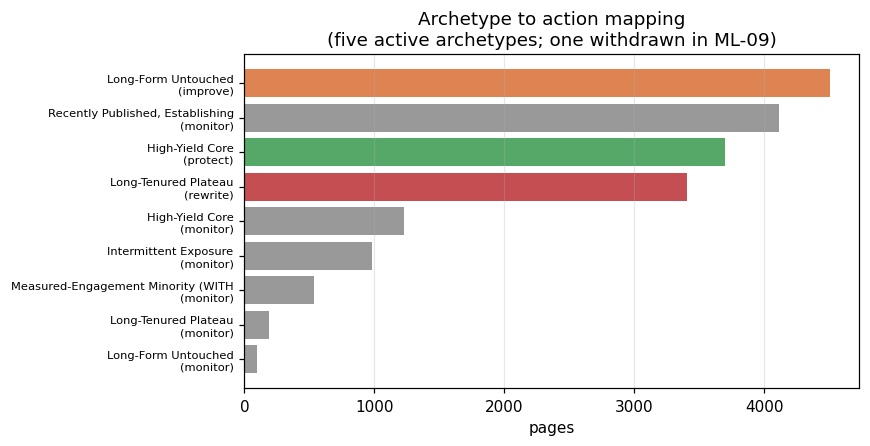

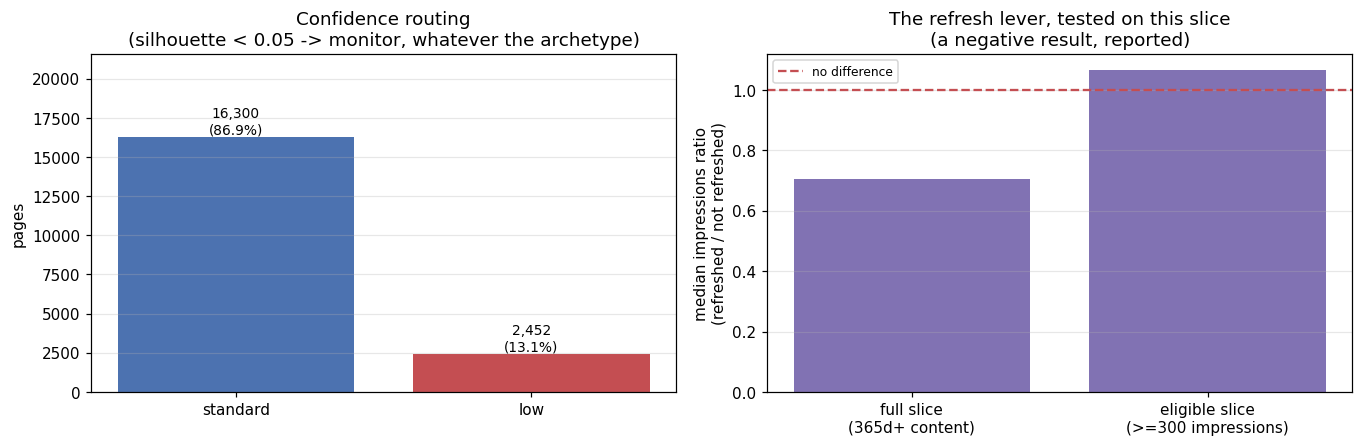

In [8]:
# ---------- figures for the paper: work/figures/ ----------
COLORS = {"protect":"#55A868","improve":"#DD8452","rewrite":"#C44E52","monitor":"#999999"}

fig, ax = plt.subplots(figsize=(8, 4.2))
mix = d.groupby(["archetype","action"], observed=True).size().reset_index(name="pages")
mix = mix.sort_values("pages")
ax.barh(range(len(mix)), mix["pages"], color=[COLORS[a] for a in mix["action"]])
ax.set_yticks(range(len(mix)))
ax.set_yticklabels([f"{a[:34]}\n({act})" for a, act in zip(mix["archetype"], mix["action"])], fontsize=7.5)
ax.set_xlabel("pages"); ax.set_title("Archetype to action mapping\n(five active archetypes; one withdrawn in ML-09)")
ax.grid(axis="x", alpha=0.3); fig.tight_layout()
fig.savefig(FIG / "playbook_archetype_actions.png", dpi=120, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
conf = d["confidence"].value_counts()
axes[0].bar(conf.index, conf.values, color=["#4C72B0","#C44E52"])
for i, v in enumerate(conf.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(d)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("pages"); axes[0].set_ylim(0, len(d)*1.15)
axes[0].set_title(f"Confidence routing\n(silhouette < {CONFIDENCE_FLOOR} -> monitor, whatever the archetype)")
axes[0].grid(axis="y", alpha=0.3)

bars = ["full slice\n(365d+ content)", "eligible slice\n(>=300 impressions)"]
vals = [ratio_full, g2.loc[True,"median_impressions"]/max(g2.loc[False,"median_impressions"],1)]
axes[1].bar(bars, vals, color="#8172B3")
axes[1].axhline(1.0, color="#C44E52", ls="--", lw=1.5, label="no difference")
axes[1].set_ylabel("median impressions ratio\n(refreshed / not refreshed)")
axes[1].set_title("The refresh lever, tested on this slice\n(a negative result, reported)")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "playbook_confidence_and_refresh.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"wrote {FIG}/playbook_archetype_actions.png")
print(f"wrote {FIG}/playbook_confidence_and_refresh.png")
print("     ^ COMMIT THESE - the paper reuses them")
print(f"\nEXPORT MANIFEST for next week's paper:")
for p in sorted(list(OUT.glob('*.json')) + list(FIG.glob('*.png'))):
    print(f"  {p}  ({p.stat().st_size:,} bytes)")
print(f"  {queue_path}  (regenerated, not committed)")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Intended use** — section 2, with a valid/not-valid table
- [x] **Ranked actions + reason codes** — section 1: five archetypes, one reason code per row, a
      transparent priority score, and a low-confidence route that overrides the archetype
- [x] **Archetype → action mapping** — section 1, with the withdrawn archetype shown as withdrawn
- [x] **The decay/refresh insight** — section 1, reported as a **negative result** with its caveats and its
      consequence for the playbook
- [x] **Human review** — section 3, four checks in order
- [x] **No-go list** — section 3, six rules plus a meta-rule
- [x] **Cost/value thinking** — section 4, with an explicit refusal to produce an ROI number
- [x] **Monitoring / retrain triggers** — section 4, six triggers with thresholds and cadences
- [x] **Exports for the paper** — section 5: queue CSV to `work/outputs/` (gitignored, regenerated),
      metrics JSON to `work/outputs/`, two figures to `work/figures/`
- [x] **Practical and non-production** — no deployment, no API, no automation; the monitoring plan is
      explicitly the version a small team could run by hand

### What next week's paper inherits

| File | What it carries |
|---|---|
| `work/outputs/playbook_metrics.json` | every number in the recommendations section |
| `work/outputs/validation_metrics.json` | the honest-split numbers behind the limits section |
| `work/outputs/model_metrics.json` | method comparison and cluster profiles |
| `work/outputs/baseline_metrics.json` | the hand-written ladder the clustering is compared against |
| `work/figures/playbook_archetype_actions.png` | the recommendations figure |
| `work/figures/playbook_confidence_and_refresh.png` | the confidence routing and the negative refresh result |

**The three sentences the paper has to carry, and their evidence:**

1. *Observed:* six behavioural groups reproduce across seeds (ARI 0.998) on 18,752 pages from 29
   pseudonymized clients — **five** of them also survive removing a single feature.
2. *Measured:* leave-one-client-out across 17 clients gives mean ARI 0.909, with 3 clients below 0.80 and a
   worst case of 0.465 — portability is directional, not reliable.
3. *Decision-support:* the result is a ranked review queue with reason codes, an explicit low-confidence
   bucket, and no automated action of any kind.

And the sentence I am most glad the playbook contains: **on this slice, recent refresh showed no measured
association with higher visibility** — a finding I would have skipped if I had imported a headline instead
of testing it.